In [1]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn scipy statsmodels
!{sys.executable} -m pip install scikit-posthocs


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import os

# Directories
PROCESSED_DIR = r"C:\Users\HP\Desktop\thesis_preprocessing\data\processed"
OUTPUT_DIR = r"C:\Users\HP\Desktop\thesis_preprocessing\outputs"
FIGURES_DIR = os.path.join(OUTPUT_DIR, "figures")

os.makedirs(FIGURES_DIR, exist_ok=True)
LOG_FILE = os.path.join(OUTPUT_DIR, "Experiment_Statistical_Results.txt")

# Clear the log file if it exists so we start fresh on each run
with open(LOG_FILE, "w", encoding="utf-8") as f:
    f.write("=== THESIS STATISTICAL RESULTS LOG ===\n\n")

def log_result(text):
    print(text)
    with open(LOG_FILE, "a", encoding="utf-8") as f:
        f.write(text + "\n")

# Load the scored datasets
df_orig = pd.read_csv(os.path.join(PROCESSED_DIR, "01_Original_12k_scored.csv"))
df_dist_a = pd.read_csv(os.path.join(PROCESSED_DIR, "02_Distractor_A_Swapped_12k_scored.csv"))
df_dist_b = pd.read_csv(os.path.join(PROCESSED_DIR, "03_Distractor_B_Shuffled_12k_scored.csv"))

df_orig = df_orig.dropna(subset=['codebert_score', 'adak_index']).copy()
df_dist_a = df_dist_a.dropna(subset=['codebert_score', 'adak_index']).copy()
df_dist_b = df_dist_b.dropna(subset=['codebert_score', 'adak_index']).copy()

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12})

log_result("Data loaded successfully. Output directories mapped.")

Data loaded successfully. Output directories mapped.



Test A: Swapped Distractors (Topic Distortion)
Feature Importances:
  Adak Index: 0.3346
  CodeBERT:   0.6654

Confusion Matrix:
[[1336 1073]
 [1118 1273]]

Classification Report:
                precision    recall  f1-score   support

Distractor (0)       0.54      0.55      0.55      2409
     Valid (1)       0.54      0.53      0.54      2391

      accuracy                           0.54      4800
     macro avg       0.54      0.54      0.54      4800
  weighted avg       0.54      0.54      0.54      4800


Test B: Shuffled Distractors (Grammar Distortion)
Feature Importances:
  Adak Index: 0.5020
  CodeBERT:   0.4980

Confusion Matrix:
[[1918  491]
 [ 677 1714]]

Classification Report:
                precision    recall  f1-score   support

Distractor (0)       0.74      0.80      0.77      2409
     Valid (1)       0.78      0.72      0.75      2391

      accuracy                           0.76      4800
     macro avg       0.76      0.76      0.76      4800
  weighted avg

C:\Users\HP\AppData\Local\Temp\ipykernel_3992\712726565.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Adak Index', 'CodeBERT Score'], y=imp_a, palette='Blues')


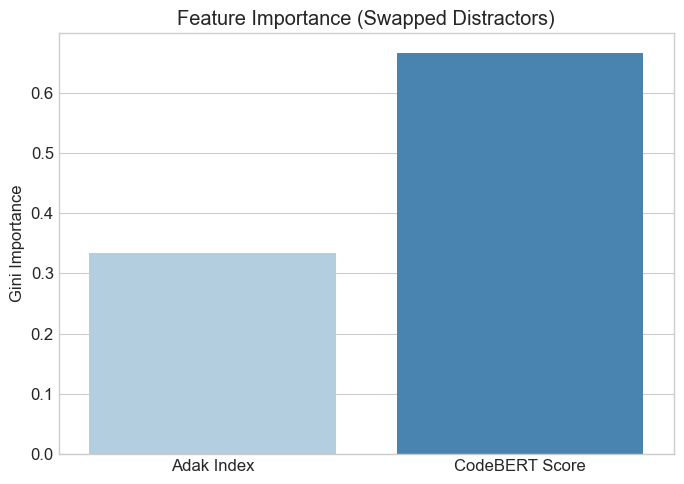

C:\Users\HP\AppData\Local\Temp\ipykernel_3992\712726565.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Adak Index', 'CodeBERT Score'], y=imp_b, palette='Reds')


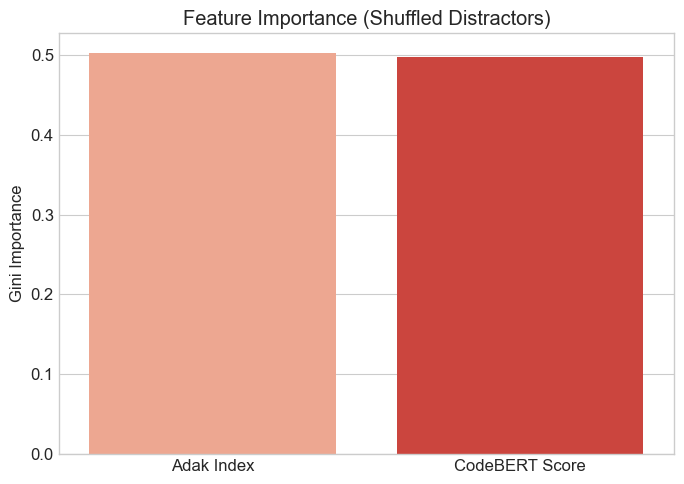

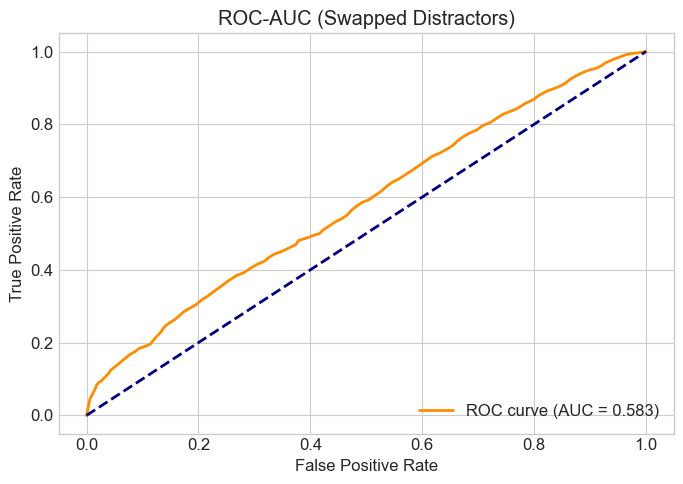

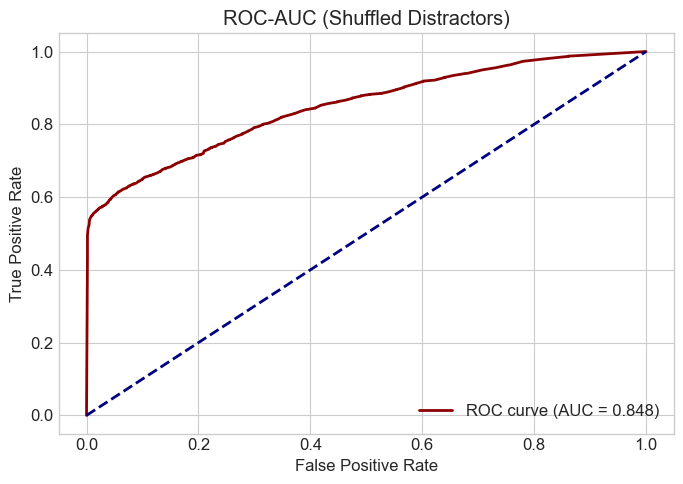

In [3]:
def run_detailed_rf(df_real, df_fake, experiment_name):
    log_result(f"\n{'='*50}\n{experiment_name}\n{'='*50}")
    
    df_combined = pd.concat([df_real, df_fake], ignore_index=True)
    X = df_combined[['adak_index', 'codebert_score']]
    y = df_combined['label']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    
    y_pred = rf.predict(X_test)
    y_prob = rf.predict_proba(X_test)[:, 1]
    
    importances = rf.feature_importances_
    conf_matrix = confusion_matrix(y_test, y_pred)
    class_report = classification_report(y_test, y_pred, target_names=['Distractor (0)', 'Valid (1)'])
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    log_result(f"Feature Importances:\n  Adak Index: {importances[0]:.4f}\n  CodeBERT:   {importances[1]:.4f}\n")
    log_result(f"Confusion Matrix:\n{conf_matrix}\n")
    log_result(f"Classification Report:\n{class_report}")
    
    return importances, fpr, tpr, roc_auc

imp_a, fpr_a, tpr_a, auc_a = run_detailed_rf(df_orig, df_dist_a, "Test A: Swapped Distractors (Topic Distortion)")
imp_b, fpr_b, tpr_b, auc_b = run_detailed_rf(df_orig, df_dist_b, "Test B: Shuffled Distractors (Grammar Distortion)")

# ---------------------------------------------------------
# SEPARATED VISUALIZATIONS FOR EXPERIMENT 1
# ---------------------------------------------------------

# 1. Feature Importance (Swapped)
plt.figure(figsize=(7, 5))
sns.barplot(x=['Adak Index', 'CodeBERT Score'], y=imp_a, palette='Blues')
plt.title('Feature Importance (Swapped Distractors)')
plt.ylabel('Gini Importance')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "Exp1_Feature_Importance_Swapped.png"), dpi=300, bbox_inches='tight')
plt.show()

# 2. Feature Importance (Shuffled)
plt.figure(figsize=(7, 5))
sns.barplot(x=['Adak Index', 'CodeBERT Score'], y=imp_b, palette='Reds')
plt.title('Feature Importance (Shuffled Distractors)')
plt.ylabel('Gini Importance')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "Exp1_Feature_Importance_Shuffled.png"), dpi=300, bbox_inches='tight')
plt.show()

# 3. ROC Curve (Swapped)
plt.figure(figsize=(7, 5))
plt.plot(fpr_a, tpr_a, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_a:.3f})')
plt.plot([0, 1],[0, 1], color='navy', lw=2, linestyle='--')
plt.title('ROC-AUC (Swapped Distractors)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "Exp1_ROC_Curve_Swapped.png"), dpi=300, bbox_inches='tight')
plt.show()

# 4. ROC Curve (Shuffled)
plt.figure(figsize=(7, 5))
plt.plot(fpr_b, tpr_b, color='darkred', lw=2, label=f'ROC curve (AUC = {auc_b:.3f})')
plt.plot([0, 1],[0, 1], color='navy', lw=2, linestyle='--')
plt.title('ROC-AUC (Shuffled Distractors)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "Exp1_ROC_Curve_Shuffled.png"), dpi=300, bbox_inches='tight')
plt.show()


Experiment 2: Paradigm Bias Analysis (Kruskal-Wallis)
Kruskal-Wallis Results:
H-Statistic: 1104.8482 | p-value: 1.2169e-240

Conclusion: Significant variance exists between programming paradigms.
                 Object-Oriented     Procedural      Scripting
Object-Oriented     1.000000e+00   3.680789e-96   6.011903e-43
Procedural          3.680789e-96   1.000000e+00  4.772400e-239
Scripting           6.011903e-43  4.772400e-239   1.000000e+00


C:\Users\HP\AppData\Local\Temp\ipykernel_3992\283475527.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='paradigm', y='adak_index', data=df_orig, showfliers=False, palette='Set2')


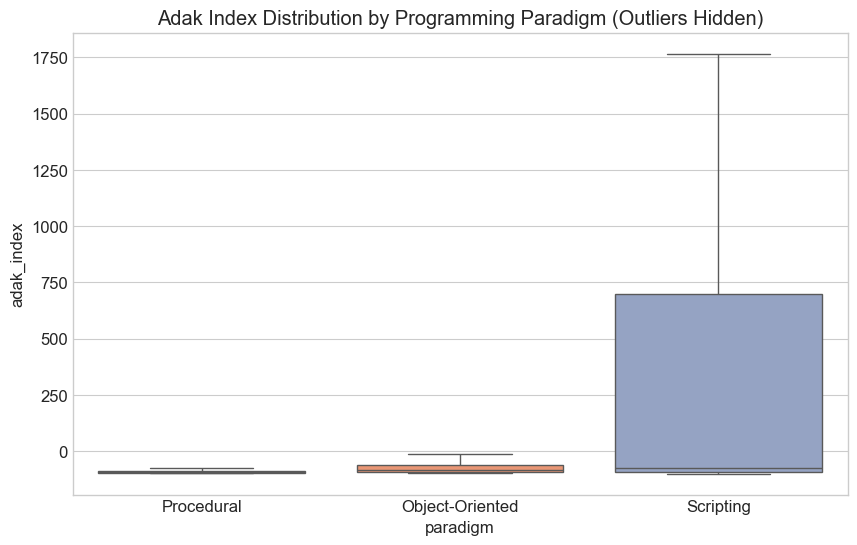

In [4]:
import scikit_posthocs as sp 

log_result(f"\n{'='*50}\nExperiment 2: Paradigm Bias Analysis (Kruskal-Wallis)\n{'='*50}")

# Map languages to programming paradigms
paradigm_map = {
    'java': 'Object-Oriented', 'ruby': 'Object-Oriented',
    'go': 'Procedural',
    'python': 'Scripting', 'javascript': 'Scripting', 'php': 'Scripting'
}
df_orig['paradigm'] = df_orig['language'].str.lower().map(paradigm_map)

# Kruskal-Wallis Test
paradigms = df_orig['paradigm'].dropna().unique()
adak_groups = [df_orig[df_orig['paradigm'] == p]['adak_index'] for p in paradigms]

h_stat, p_value = stats.kruskal(*adak_groups)
log_result(f"Kruskal-Wallis Results:\nH-Statistic: {h_stat:.4f} | p-value: {p_value:.4e}\n")

if p_value < 0.05:
    log_result("Conclusion: Significant variance exists between programming paradigms.")
    # Dunn's Post-Hoc Test
    dunn_results = sp.posthoc_dunn(df_orig, val_col='adak_index', group_col='paradigm', p_adjust='bonferroni')
    log_result(str(dunn_results))
else:
    log_result("Conclusion: No significant variance between paradigms.")

# Visualization
plt.figure(figsize=(10, 6))
sns.boxplot(x='paradigm', y='adak_index', data=df_orig, showfliers=False, palette='Set2')
plt.title('Adak Index Distribution by Programming Paradigm (Outliers Hidden)')
plt.savefig(os.path.join(FIGURES_DIR, "Exp2_Paradigm_Bias.png"), dpi=300, bbox_inches='tight')
plt.show()


Experiment 3: Complexity Threshold Analysis
Overall Baseline Spearman Correlation: 0.3396 (p-value: 0.0000e+00)

Spearman Correlation by Complexity Segment:
Bucket: Small (SFV < 15) (n=5782)
Spearman Correlation: -0.2133 (p-value: 1.8248e-60)

Bucket: Medium (SFV 15-40) (n=4305)
Spearman Correlation: 0.6824 (p-value: 0.0000e+00)

Bucket: Large (SFV > 40) (n=1913)
Spearman Correlation: 0.8283 (p-value: 0.0000e+00)



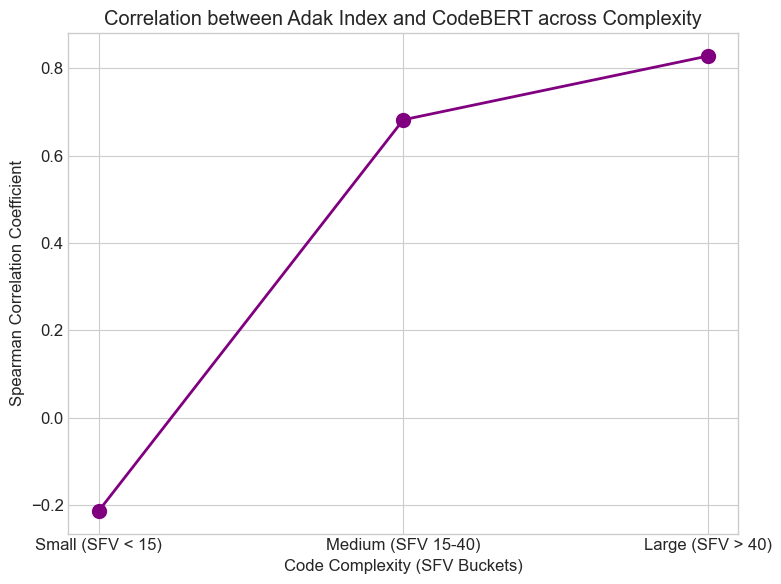

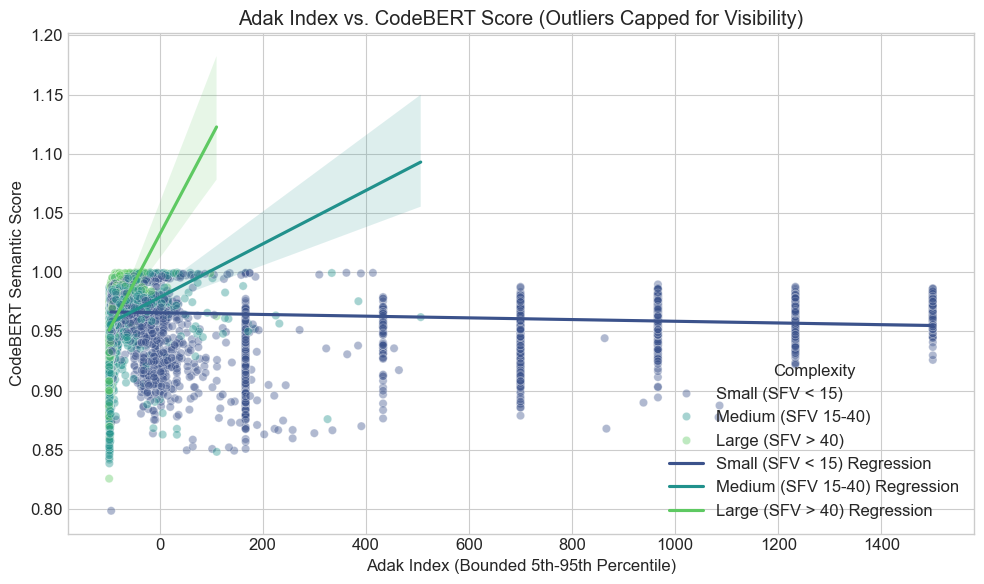

In [5]:
log_result(f"\n{'='*50}\nExperiment 3: Complexity Threshold Analysis\n{'='*50}")

overall_corr, overall_pval = stats.spearmanr(df_orig['adak_index'], df_orig['codebert_score'])
log_result(f"Overall Baseline Spearman Correlation: {overall_corr:.4f} (p-value: {overall_pval:.4e})\n")

bins =[0, 15, 40, np.inf]
labels =['Small (SFV < 15)', 'Medium (SFV 15-40)', 'Large (SFV > 40)']
df_orig['complexity_bucket'] = pd.cut(df_orig['sfv'], bins=bins, labels=labels)

buckets = labels
correlations =[]

log_result("Spearman Correlation by Complexity Segment:")
for bucket in buckets:
    subset = df_orig[df_orig['complexity_bucket'] == bucket]
    if len(subset) > 1:
        corr, p_val = stats.spearmanr(subset['adak_index'], subset['codebert_score'])
        correlations.append(corr)
        log_result(f"Bucket: {bucket} (n={len(subset)})")
        log_result(f"Spearman Correlation: {corr:.4f} (p-value: {p_val:.4e})\n")
    else:
        correlations.append(0)

# ---------------------------------------------------------
# SEPARATED VISUALIZATIONS FOR EXPERIMENT 3
# ---------------------------------------------------------

# 1. Degradation Line Curve
plt.figure(figsize=(8, 6))
plt.plot(buckets, correlations, marker='o', color='purple', linewidth=2, markersize=10)
plt.title('Correlation between Adak Index and CodeBERT across Complexity')
plt.xlabel('Code Complexity (SFV Buckets)')
plt.ylabel('Spearman Correlation Coefficient')
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "Exp3_Correlation_Curve.png"), dpi=300, bbox_inches='tight')
plt.show()

# 2. Scatter Plots with Regression Lines
plt.figure(figsize=(10, 6))

# Cap the X-axis to the 5th and 95th percentile to prevent extreme outliers from ruining the visual scale
adak_lower, adak_upper = df_orig['adak_index'].quantile([0.05, 0.95])
filtered_df = df_orig[(df_orig['adak_index'] >= adak_lower) & (df_orig['adak_index'] <= adak_upper)]

sns.scatterplot(data=filtered_df, x='adak_index', y='codebert_score', hue='complexity_bucket', 
                palette='viridis', alpha=0.4)

colors = sns.color_palette('viridis', 3)
for idx, bucket in enumerate(buckets):
    bucket_data = filtered_df[filtered_df['complexity_bucket'] == bucket]
    if len(bucket_data) > 1:
        sns.regplot(data=bucket_data, x='adak_index', y='codebert_score', 
                    scatter=False, line_kws={'color': colors[idx]}, label=f'{bucket} Regression')

plt.title('Adak Index vs. CodeBERT Score (Outliers Capped for Visibility)')
plt.xlabel('Adak Index (Bounded 5th-95th Percentile)')
plt.ylabel('CodeBERT Semantic Score')
plt.legend(title='Complexity', loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "Exp3_Scatter_Regression.png"), dpi=300, bbox_inches='tight')
plt.show()